<img height='100' src='logotmg.png' width='900' alt='Talia Morchi' id='tmg_logo' title='Data Analyst Course'>
<center><h1><u>Welcome to the python for data analysis course </u></h1></center><center><h2>Class 8</h2></center>

## Import libraries

In [ ]:
import numpy as np
import pandas as pd

#Visualization Libraries
import seaborn as sns
import matplotlib.pyplot as plt

#To plot the graph embedded in the notebook
%matplotlib inline

#### Now we need to import important modules from the sklearn


In [2]:
# Import sklearn in build data set
from sklearn import datasets

# Package that build our model
from sklearn.linear_model import LinearRegression

# Package that split the data into train and test group, and check the model
from sklearn.model_selection import train_test_split, cross_val_score

# Check the model performance / accuracy using ,Mean Squered Error (MSE) 
from sklearn.metrics import mean_squared_error

## 1. Problem Definition

The objective is to predict the value of prices of the house using the given features

## 2. Data collection
We use the Boston Housing dataset, that  contains information about various houses in Boston through different parameters

In [3]:
#loading the dataset direclty from sklearn
boston = datasets.load_boston()
boston

{'data': array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
         4.9800e+00],
        [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
         9.1400e+00],
        [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
         4.0300e+00],
        ...,
        [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         5.6400e+00],
        [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
         6.4800e+00],
        [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         7.8800e+00]]),
 'target': array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
        18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
        15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
        13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
        21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
        35.4, 24.7, 3

sklearn returns Dictionary-like object with the attributes: 
* data - the data to learn, independent variable (x value)
* target - the regression targets, dependent variable (y values) 
* feature_names - column names
* DESCR - the full description of the dataset 
* filename - the physical location of boston csv dataset

In [4]:

print('Structure type of the Boston data:\n',type(boston))
print('\n')
print('Attributes in the Boston data:\n',boston.keys())
print('\n')
print('Shape of the data:\n', boston.data.shape)
print('\n')
print('feature (column) names:\n', boston.feature_names)

Structure type of the Boston data:
 <class 'sklearn.utils.Bunch'>


Attributes in the Boston data:
 dict_keys(['data', 'target', 'feature_names', 'DESCR', 'filename'])


Shape of the data:
 (506, 13)


feature (column) names:
 ['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']


In [5]:
# Print details about the features and more information about the dataset 

print(boston.DESCR)

.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pu

<img height="100" src="Boston_feaure_heb.png" width="801" alt="Hands on" id="prc_time" title="Data Analyst Course">

#### Convert to pandas df

In [6]:
# Transform dataset into DataFrame
# boston.data = contains all the features
# boston.targer = contains the target variable (what we want to predict)

bos = pd.DataFrame(boston.data, columns = boston.feature_names)
bos['PRICE'] = boston.target

bos.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7


## 3. Data cleaning

In [7]:
# There are 506 samples and 13 feature variables in this dataset
bos.shape

(506, 14)

In [8]:
# There is no missing values
bos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [9]:
# After loading the data, it’s better to see if there are any missing values in the data
# There are no null values in the dataset
bos
bos.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [10]:
bos.describe()
# print (bos.describe())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## 4.EDA - Exploratory Data Analysis

Exploratory Data Analysis is a very important step before training the model

Using visualizations to understand the relationship of the target variable with other features

#### Distribution of the target variable

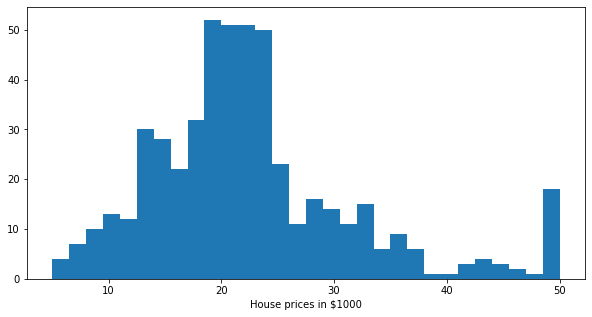

In [11]:
# using histogram
plt.figure(figsize=(10,5))

plt.hist(bos['PRICE'], bins=30)

plt.xlabel("House prices in $1000")
plt.show()

We can see from the plot that the values of PRICE are distributed normally with few outliers. 

Most of the house are around 20–24 range (in $1000 scale)

#### Created a dataframe without target variable

In [12]:
# Created a dataframe without the price col, since we need to see the correlation between the variables
bos_x = pd.DataFrame(boston.data, columns = boston.feature_names)

#### Correlation matrix

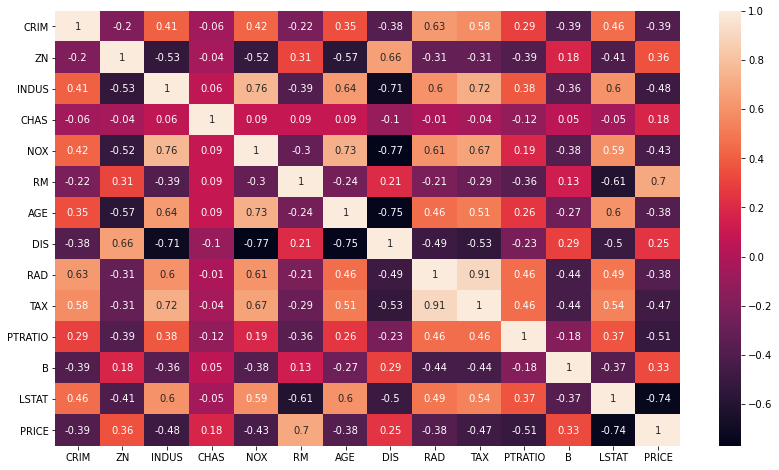

In [13]:
# create correlation matrix that measures the linear relationships between the variables
# The correlation coefficient ranges from -1 to 1
# When value is close to 1, it means that there is a strong positive correlation between the two variables
# When value is close to -1, the variables have a strong negative correlation
plt.figure(figsize=(14, 8))
correlation_matrix = bos.corr().round(2)
correlation_matrix

sns.heatmap(data=correlation_matrix, annot=True)

#### Conclusion from heatmap
1. RM has a strong positive correlation with PRICE (0.7) where as LSTAT has a high negative correlation with PRICE (-0.74)


2. An important point in selecting features for a linear regression model is to check for multicolinearity. The features RAD, TAXhave a correlation of 0.91. These feature pairs are strongly correlated to each other. This can affect the model. Same goes for the features DIS and AGE which have a correlation of -0.75


* Multicollinearity exists whenever an independent variable is highly correlated with one or more of the other independent variables in a multiple regression equation. Multicollinearity is a problem because it undermines the statistical significance of an independent variable.

#### Check correlation between PRICE and RM, LSTAT

Enumerate
* Enumerate is a built-in function of Python
* It allows us to loop over something and have an automatic counter
* Check notebook about Enumerate (in the current folder)

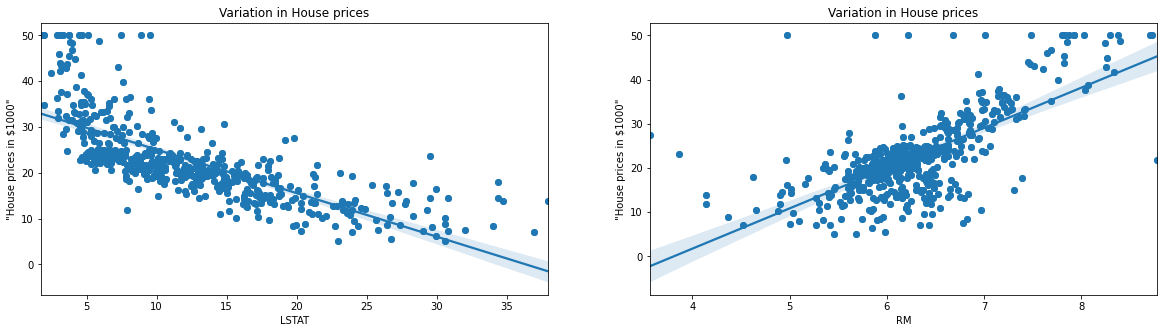

In [17]:
plt.figure(figsize=(20, 5))

features = ['LSTAT', 'RM']
target = bos['PRICE']

for i, item in enumerate(features):
    
    plt.subplot(1, len(features) , i+1)
    
    x = bos[item]
    y = target
    
    # Scatter plot
    plt.scatter(x, y, marker='o')
    
    # Scatter plot with regression line    
#     sns.regplot(x, y)
    
    # Add labels     
    plt.title("Variation in House prices")
    plt.xlabel(item)
    plt.ylabel('"House prices in $1000"')

1. The prices increase as the value of RM increases linearly. There are few outliers and the data seems to be capped at 50.
2. The prices tend to decrease with an increase in LSTAT. Though it doesn’t look to be following exactly a linear line.

## 5. Build predictive model - Based on 1 dependent variable
Since you saw that ‘RM’ shows positive correlation with the House Prices we will use this variable

#### predict the house price

In [18]:
# RM shows positive correlation with the House Prices >> we will use this variable
X_rooms = bos.RM
y_price = bos.PRICE

# reshape the array to unknown rows and 1 column
X_rooms = np.array(X_rooms).reshape(-1,1)
y_price = np.array(y_price).reshape(-1,1)

print(X_rooms.shape)
print(y_price.shape)

(506, 1)
(506, 1)


#### Splitting the data into training and testing sets
* We need to test our model, therefore we split the data into training and testing sets
* We train the model with 70% of the samples and test with the remaining 30% 
* We do this to assess the model’s performance on unseen data

In [19]:
# use train_test_split function provided by sklean
# Use Parameter: random_state=number = everytime you run it without specifying random_state, 
#                                      you will get a different result, this is expected behavior

X_train_1, X_test_1, Y_train_1, Y_test_1 = train_test_split(X_rooms, y_price, test_size = 0.3, random_state=42)

print(X_train_1.shape)
print(X_test_1.shape)
print(Y_train_1.shape)
print(Y_test_1.shape)


(354, 1)
(152, 1)
(354, 1)
(152, 1)


#### Training and testing the model
* We use scikit-learn’s LinearRegression to train our model on both the training and check it on the test sets
* We check the model performance on the train dataset

In [20]:
# Create linear regression
reg_1 = LinearRegression()

type (reg_1)

sklearn.linear_model._base.LinearRegression

In [21]:
# Fit linear model
# Adding the x and y train data

reg_1.fit(X_train_1, Y_train_1)

LinearRegression()

In [22]:
# print the intercept of our model
# f(x) = b0 + b1*x1 = y >>  b1 is the coeficients, b0 is the intercept
# f(x) = b0 + b1*x1 + b2*x2... = y >> b1 and b2 are the coeficients, b0 is the intercept
print(reg_1.intercept_)

[-34.66230744]


In [23]:
# print the coeficients/weights for each feature/column of our model

# we have coeficient for each of the dependent variables
print (reg_1.coef_)

[[9.1181022]]


## 6. Validate model 

In [29]:
# Get the predictions of the model

y_train_predict_1 = reg_1.predict(X_train_1)

#### Regression Error Metrics in Python
* MAE - Mean absolute error
* MSE - Mean square error
* RMSE - root mean squared error 
* MAPE (problematic, less used) - Mean absolute percentage error

In [30]:
# from sklearn import metrics
# print('MAE:', metrics.mean_absolute_error(Y_train_1, y_train_predict_1))
# print('MSE:', metrics.mean_squared_error(Y_train_1, y_train_predict_1))
# print('RMSE:', np.sqrt(metrics.mean_squared_error(Y_train_1, y_train_predict_1)))
# print('r2_score:', metrics.r2_score(Y_train_1, y_train_predict_1))


MAE: 4.5030631562319705
MSE: 45.01275449524407
RMSE: 6.709154529092624
r2_score: 0.4878892853275991


#### RMSE - Root mean square error
* RMSE is a method of measuring the difference between values predicted by a model and their actual values
* It tells you how concentrated the data is around the line of best fit


In [31]:
# To calculate the RMSE, we use the MSE method, and take its root

mean_squared_error(Y_train_1, y_train_predict_1)
# np.sqrt(mean_squared_error(Y_train_1, y_train_predict_1))

# rmse = (np.sqrt(mean_squared_error(Y_train_1, y_train_predict_1)))

In [32]:
# Get the model score
r2 = round(reg_1.score(X_train_1, Y_train_1),2)
r2

0.49

In [33]:
# Print results
print("The model performance for training set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))
print("\n")

The model performance for training set
--------------------------------------
RMSE is 6.709154529092624
R2 score is 0.49




## 6. Deployment

In [34]:
# model evaluation for test set
y_pred_1 = reg_1.predict(X_test_1)

# Check for std
rmse = (np.sqrt(mean_squared_error(Y_test_1, y_pred_1)))
r2 = round(reg_1.score(X_test_1, Y_test_1),2)

# print results
print("The model performance for test set")
print("--------------------------------------")
print("Root Mean Squared Error: {}".format(rmse))
print("R^2: {}".format(r2))
print("\n")


The model performance for test set
--------------------------------------
Root Mean Squared Error: 6.352279094771658
R^2: 0.46




#### Plotting the model fitted line on the output variable.

In [35]:
# np.linspace (start, stop, number_of_items) = Return evenly spaced numbers over a specified interval
np.linspace (1,5)

array([1.        , 1.08163265, 1.16326531, 1.24489796, 1.32653061,
       1.40816327, 1.48979592, 1.57142857, 1.65306122, 1.73469388,
       1.81632653, 1.89795918, 1.97959184, 2.06122449, 2.14285714,
       2.2244898 , 2.30612245, 2.3877551 , 2.46938776, 2.55102041,
       2.63265306, 2.71428571, 2.79591837, 2.87755102, 2.95918367,
       3.04081633, 3.12244898, 3.20408163, 3.28571429, 3.36734694,
       3.44897959, 3.53061224, 3.6122449 , 3.69387755, 3.7755102 ,
       3.85714286, 3.93877551, 4.02040816, 4.10204082, 4.18367347,
       4.26530612, 4.34693878, 4.42857143, 4.51020408, 4.59183673,
       4.67346939, 4.75510204, 4.83673469, 4.91836735, 5.        ])

In [36]:
prediction_space = np.linspace(min(X_rooms), max(X_rooms)).reshape(-1,1) 

# Explanation:
# min(X_rooms)
# max(X_rooms)
# np.linspace(min(X_rooms), max(X_rooms))
# np.linspace(min(X_rooms), max(X_rooms)).reshape(-1,1)

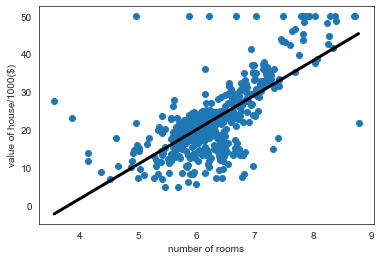

In [37]:
sns.set_style('white')

# Scatter plot
plt.scatter(X_rooms,y_price)

# Regression line
# Takes the x from prediction_space, and using the prediction model - evaluate the y value
plt.plot(prediction_space, reg_1.predict(prediction_space), color = 'black', linewidth = 3)

# Change labels
plt.ylabel('value of house/1000($)')
plt.xlabel('number of rooms')
plt.show()

## Regression Model for All the variables

#### Create the model

In [38]:
# Set the x and y values
# x = all the features without the target
# y = the target
X = bos.drop('PRICE', axis = 1)
y = bos['PRICE']

# split to train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

# Fit the model
reg_all = LinearRegression()
reg_all.fit(X_train, y_train)

# model evaluation for training set
y_train_predict = reg_all.predict(X_train)
rmse = (np.sqrt(mean_squared_error(y_train, y_train_predict)))
r2 = round(reg_all.score(X_train, y_train),2)

# print the results
print("The model performance for training set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))
print("\n")


The model performance for training set
--------------------------------------
RMSE is 4.748208239685937
R2 score is 0.74




In [39]:
print(reg_all.intercept_)

31.63108403569186


In [40]:
print (reg_all.coef_)

[-1.33470103e-01  3.58089136e-02  4.95226452e-02  3.11983512e+00
 -1.54170609e+01  4.05719923e+00 -1.08208352e-02 -1.38599824e+00
  2.42727340e-01 -8.70223437e-03 -9.10685208e-01  1.17941159e-02
 -5.47113313e-01]


#### Evaluate on test set

In [41]:
# model evaluation for test set
# predict y using the model we created
y_pred = reg_all.predict(X_test)

# calculate the std
rmse = (np.sqrt(mean_squared_error(y_test, y_pred)))
r2 = round(reg_all.score(X_test, y_test),2)

# print results
print("The model performance for test set")
print("--------------------------------------")
print("Root Mean Squared Error: {}".format(rmse))
print("R^2: {}".format(r2))
print("\n")

The model performance for test set
--------------------------------------
Root Mean Squared Error: 4.6386899261728445
R^2: 0.71




Text(0.5, 1.0, 'Actual Prices vs Predicted prices')

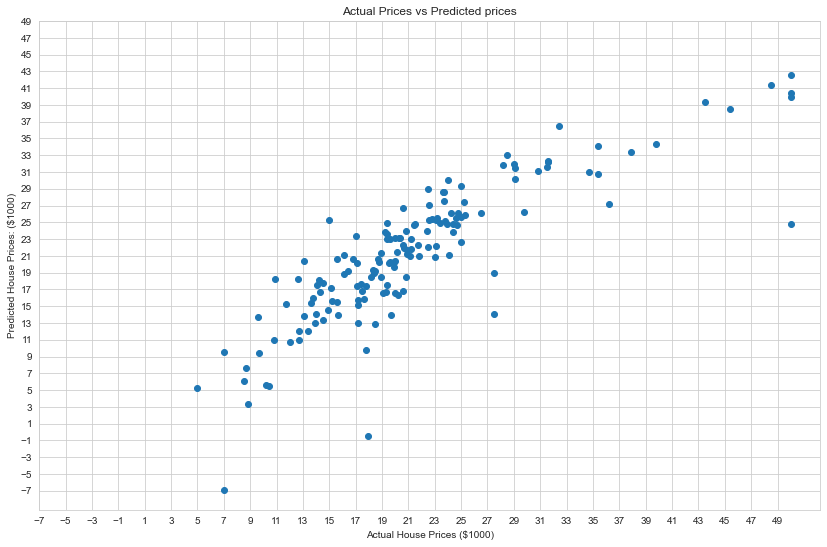

In [42]:
# Check the model predictins 
# Plotting a scatter plot between the original house price and predicted house prices.

sns.set_style('whitegrid')
plt.figure(figsize=(14, 9))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices ($1000)")
plt.ylabel("Predicted House Prices: ($1000)")

plt.xticks(range(-7, int(max(y_test)),2))
plt.yticks(range(-7, int(max(y_test)),2))

plt.title("Actual Prices vs Predicted prices")
